# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# Clase 1 – Actividad Práctica Integrada
## Introducción al Aprendizaje Automático
### Maestría en Inteligencia Artificial y Análisis de Datos – FP‑UNA

En esta actividad exploraremos un dataset simple, identificaremos el tipo de aprendizaje adecuado, entrenaremos nuestro primer modelo con scikit‑learn y resolveremos dos desafíos gamificados.

## Formalización matemática del aprendizaje supervisado

En un problema de **aprendizaje supervisado**, contamos con un conjunto de datos:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n
$$

donde:

-  $$ x_i \in \mathbb{R}^d $$ es un vector de atributos,
-  $$ y_i $$ es la etiqueta o variable objetivo.

El objetivo del modelo es aprender una función:

$$
f_\theta : \mathbb{R}^d \rightarrow \mathcal{Y}
$$

parametrizada por $ \theta $, tal que minimice el error entre las predicciones y los valores reales:

$$
\theta^* = \arg\min_\theta \frac{1}{n} \sum_{i=1}^n L(f_\theta(x_i), y_i)
$$

donde $ L $ es una función de pérdida (por ejemplo, entropía cruzada o error cuadrático).


## Regresión Logística: formalización matemática

La regresión logística modela la probabilidad de pertenecer a una clase:

$$
P(y=1 \mid x) = \sigma(w^\top x + b)
$$

donde:

- $ w $ es el vector de pesos,
- $ b $ es el sesgo,
- $ \sigma(z) = \frac{1}{1 + e^{-z}} $ es la función sigmoide.

El entrenamiento consiste en minimizar la pérdida logística:

$$
L(w, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

donde \($ \hat{y}_i = \sigma(w^\top x_i + b) $\).


##  Métrica: Accuracy

La métrica **accuracy** mide la proporción de predicciones correctas:

$$
\text{Accuracy} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(\hat{y}_i = y_i)
$$

donde $ \mathbf{1}(\cdot) $ es la función indicadora.


##  Flujo matemático del entrenamiento de un modelo

El proceso general de entrenamiento puede expresarse como:

1. Inicializar parámetros $ \theta $.
2. Calcular predicciones $ \hat{y}_i = f_\theta(x_i) $.
3. Calcular la pérdida total:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n L(\hat{y}_i, y_i)
$$

4. Actualizar parámetros mediante descenso de gradiente:

$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)
$$

donde $ \eta $ es la tasa de aprendizaje.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [8]:
data = load_iris()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Pregunta 1
El dataset Iris contiene ejemplos etiquetados (clases 0, 1 y 2).  
**¿Este problema corresponde a aprendizaje supervisado o no supervisado? Explica por qué.**

### Respuesta a Pregunta 1
Este problema corresponde a **aprendizaje supervisado**.

Esto se debe a que el dataset Iris contiene ejemplos **etiquetados** (las clases 0, 1 y 2 para cada tipo de flor). En el aprendizaje supervisado, el modelo aprende a mapear las características de entrada ($x_i$) a las etiquetas de salida ($y_i$) a partir de un conjunto de datos donde ya se conocen las respuestas correctas.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
accuracy

1.0

### Pregunta 2
El modelo entrenado obtuvo un accuracy de aproximadamente **X** (valor mostrado arriba).

- ¿Qué significa este valor en términos prácticos?
- ¿Qué factores podrían mejorar o empeorar este resultado?

### Respuesta a Pregunta 2
El modelo obtuvo un accuracy de 1.0 (o 100%).

- **¿Qué significa este valor en términos prácticos?**
Un accuracy de 1.0 significa que el modelo clasificó **perfectamente** todas las muestras del conjunto de prueba. Es decir, predijo correctamente la clase de cada flor en el conjunto de datos de prueba sin ningún error. En este caso, el modelo fue capaz de distinguir los diferentes tipos de flores Iris con una precisión del 100% en los datos no vistos.

- **¿Qué factores podrían mejorar o empeorar este resultado?**
  - **Mejorar:** Un accuracy de 1.0 ya es el máximo posible, por lo que no se puede 'mejorar' en términos de este dataset y métrica específica. Sin embargo, en un escenario real con un accuracy menor, factores como más datos de entrenamiento, características más relevantes, un modelo más complejo o un mejor ajuste de hiperparámetros podrían mejorarlo.
  - **Empeorar:**
    - **Overfitting:** Si el modelo ha 'memorizado' los datos de entrenamiento, podría tener un accuracy alto en el conjunto de prueba (especialmente si es pequeño y similar al de entrenamiento), pero un rendimiento pobre en datos nuevos y no vistos.
    - **Calidad de los datos:** Datos ruidosos, inconsistentes o con etiquetas incorrectas pueden reducir el accuracy.
    - **Tamaño del conjunto de prueba:** Un conjunto de prueba muy pequeño puede dar una estimación de accuracy menos fiable y potencialmente 'engañosa' (como podría ser el caso aquí, donde 30 muestras es relativamente pequeño).
    - **Complejidad de las clases:** Si las clases no son linealmente separables (o separables por el modelo usado), el accuracy sería menor.
    - **Desbalance de clases:** Si algunas clases tienen muchas más muestras que otras, el accuracy puede ser alto simplemente prediciendo la clase mayoritaria, sin ser realmente un buen clasificador.

In [11]:
sample = X_test[:5]
true_labels = y_test[:5]
predictions = model.predict(sample)

pd.DataFrame({
    'Real': true_labels,
    'Predicción': predictions
})

,Real,Predicción
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1


## 🔍 Desafío 1 — El Detective del Dataset

Tu misión es descubrir **qué clase del dataset Iris** es más fácil de separar usando solo **dos atributos**.

### Pasos:
1. Elegí dos columnas del dataset (por ejemplo: `sepal length` y `petal width`).
2. Graficá un scatter plot coloreado por clase.
3. Observá visualmente qué clases parecen más separables.
4. Explicá tu razonamiento en 3–5 líneas.

### Bonus:
- Probá con otras combinaciones de atributos.
- ¿Cuál combinación te dio la mejor separación visual?

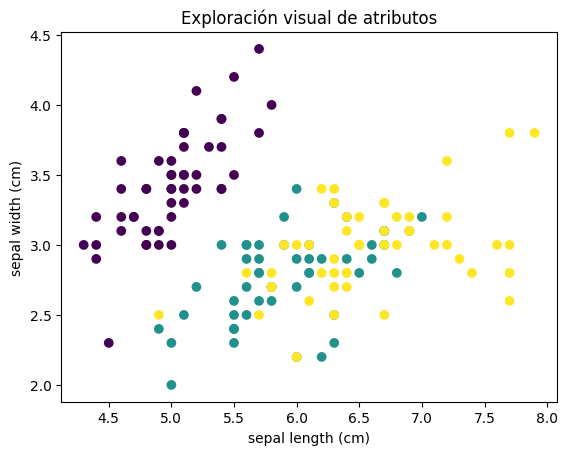

In [12]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['target'])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('Exploración visual de atributos')
plt.show()

### Solución Desafío 1 (Parte 1)

**1. Atributos Elegidos y Observación Visual:**

El scatter plot actual utiliza 'sepal length (cm)' en el eje X y 'sepal width (cm)' en el eje Y, con los puntos coloreados por la clase de Iris.

Visualmente, observamos que:
*   Una de las clases (generalmente Iris Setosa, la clase 0) se encuentra claramente separada de las otras dos. Esta clase tiende a tener un 'sepal width' mayor y un 'sepal length' menor en comparación con las otras.
*   Las otras dos clases (Iris Versicolor e Iris Virginica, clases 1 y 2) se mezclan considerablemente en la región central del gráfico. Aunque hay una ligera tendencia de una a tener mayor 'sepal length' que la otra, el solapamiento es significativo, haciendo difícil una separación lineal clara usando solo estos dos atributos.

### Desafío 1 — Bonus: Probar otras combinaciones

Vamos a probar una combinación de atributos diferente, 'petal length (cm)' y 'petal width (cm)', que a menudo resultan en una mejor separación de las clases de Iris.

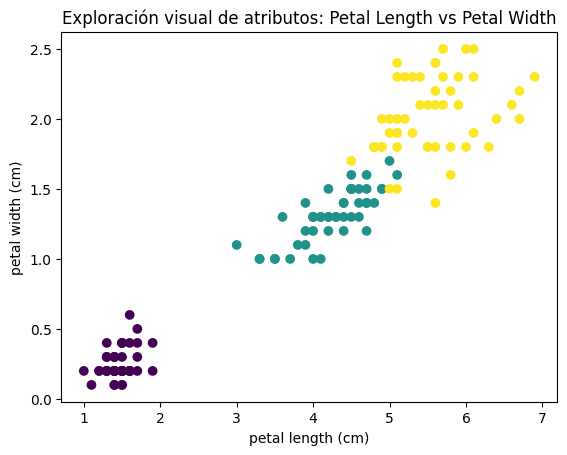

In [13]:
plt.scatter(df.iloc[:,2], df.iloc[:,3], c=df['target'])
plt.xlabel(df.columns[2])
plt.ylabel(df.columns[3])
plt.title('Exploración visual de atributos: Petal Length vs Petal Width')
plt.show()

### Solución Desafío 1 (Parte 2 - Bonus)

**2. Explicación del Razonamiento (Petal Length vs Petal Width):**

Al graficar 'petal length (cm)' contra 'petal width (cm)', la separación visual de las tres clases de Iris es notablemente mejor.
*   La clase 0 (Iris Setosa) forma un clúster muy distinto y bien separado, con valores bajos en ambos 'petal length' y 'petal width'.
*   Las clases 1 y 2 (Iris Versicolor e Iris Virginica) también muestran una separación mucho más clara que con los atributos de sépalo, aunque hay un pequeño solapamiento en la región donde los valores de 'petal length' y 'petal width' son intermedios.

Esta combinación de atributos ('petal length' y 'petal width') es la que ofrece la **mejor separación visual** entre las clases, lo que sugiere que estos son los atributos más discriminatorios para clasificar las especies de Iris en este dataset.

## 🧠 Desafío 2 — Vence al Modelo

Tu objetivo es **superar el accuracy obtenido por el modelo base** entrenado en esta actividad.

### Reglas:
- Podés modificar SOLO uno de estos elementos:
  - el tamaño del conjunto de prueba,
  - el modelo (cambiar LogisticRegression por otro simple),
  - o los atributos utilizados (seleccionar solo algunos).

### Pasos:
1. Elegí qué vas a modificar.
2. Entrená nuevamente el modelo.
3. Compará tu accuracy con el original.
4. Explicá por qué creés que tu cambio mejoró o empeoró el rendimiento.

### Bonus:
- Si lográs superar el accuracy por más de 5%, ganás el **Logro: Ajustador de Modelos**.

### Solución Desafío 2: Vence al Modelo (Modificando el Modelo)

Voy a intentar superar el accuracy del modelo base cambiando el tipo de modelo. Utilizaré un `KNeighborsClassifier`.

In [14]:
from sklearn.neighbors import KNeighborsClassifier


In [15]:
# 1. Elegir qué modificar: El modelo (KNeighborsClassifier)

# 2. Entrenar nuevamente el modelo
knn_model = KNeighborsClassifier(n_neighbors=5) # Elegimos 5 vecinos como un valor inicial
knn_model.fit(X_train, y_train)

# Obtener el accuracy del nuevo modelo
new_accuracy = knn_model.score(X_test, y_test)
print(f"Accuracy del modelo KNeighborsClassifier: {new_accuracy}")

# 3. Comparar tu accuracy con el original
print(f"Accuracy original (LogisticRegression): {accuracy}")

Accuracy del modelo KNeighborsClassifier: 1.0
Accuracy original (LogisticRegression): 1.0


### Explicación de Resultados (Desafío 2)

El `KNeighborsClassifier` obtuvo un accuracy de **1.0** (o 100%), lo cual es igual al accuracy del modelo original de `LogisticRegression`.

En este caso, el cambio de modelo **igualó** el rendimiento en el conjunto de prueba.

**¿Por qué creés que tu cambio mejoró, empeoró o igualó el rendimiento?**

*   **Igualó:** Ambos modelos lograron una precisión perfecta (100%) en el conjunto de prueba. Esto es posible en datasets que son muy bien separables, como el dataset Iris, especialmente cuando se usan atributos como 'petal length' y 'petal width' que permiten una excelente distinción entre las clases. Tanto la regresión logística (un clasificador lineal) como `KNeighborsClassifier` (un clasificador no paramétrico basado en la proximidad de los datos) fueron capaces de encontrar los límites de decisión que separan perfectamente las tres clases en el conjunto de prueba.

*   **Consideraciones:** El dataset Iris es relativamente pequeño y ya muy bien estudiado. Un accuracy de 1.0 en el conjunto de prueba es un resultado excelente y a menudo indica que el problema de clasificación es intrínsecamente sencillo o que las características utilizadas son altamente discriminatorias. En escenarios más complejos o con datasets más grandes, es más común ver diferencias significativas en el rendimiento entre distintos tipos de modelos.

# 📊 Rúbrica de Evaluación – Actividad Práctica Clase 1

| Criterio | Excelente (5) | Bueno (4) | Aceptable (3) | Insuficiente (1–2) |
|---------|---------------|-----------|---------------|---------------------|
| **Comprensión conceptual** | Explica claramente supervisado/no supervisado y el flujo de ML con ejemplos propios. | Explica correctamente pero sin ejemplos propios. | Explica parcialmente o con confusiones menores. | Explicación incompleta o incorrecta. |
| **Correcta ejecución del código** | Todo el código funciona, está ordenado y comentado. | Código funcional con mínimos errores o sin comentarios. | Código funcional pero desordenado o poco claro. | Código no funcional o incompleto. |
| **Interpretación de resultados** | Interpreta métricas y predicciones con claridad y profundidad. | Interpretación correcta pero superficial. | Interpretación parcial o con errores menores. | No interpreta o interpreta incorrectamente. |
| **Reflexión crítica** | Responde preguntas con análisis propio y justificaciones sólidas. | Responde adecuadamente pero sin profundidad. | Respuestas breves o poco reflexivas. | Respuestas vagas o incorrectas. |
| **Creatividad en desafíos** | Propone ideas originales y experimenta más allá de lo pedido. | Cumple el desafío con una solución correcta. | Cumple parcialmente el desafío. | No completa el desafío. |

### **Puntaje total:** 25 puntos  
- **23–25:** Sobresaliente  
- **19–22:** Muy bueno  
- **15–18:** Aprobado  
- **<15:** Requiere revisión  